In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Importing scanpy
!pip install scanpy
import scanpy as sc

In [ ]:
# Read in data
adata = sc.read_h5ad('/content/drive/MyDrive/bence_project_july/adata_new_assigned_0520 (2).h5ad')


/usr/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [ ]:
# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata, inplace=True)

In [ ]:
# Identify mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('mt-')  # mouse
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

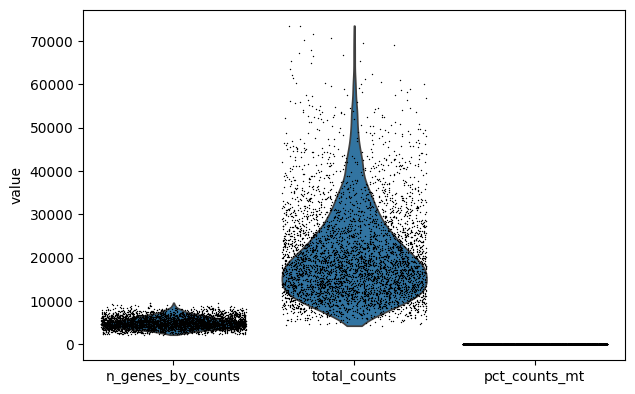

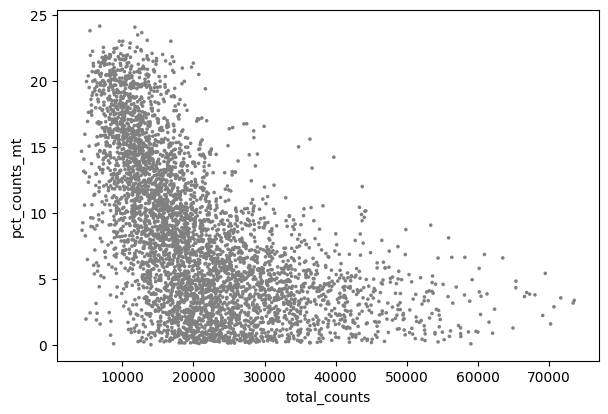

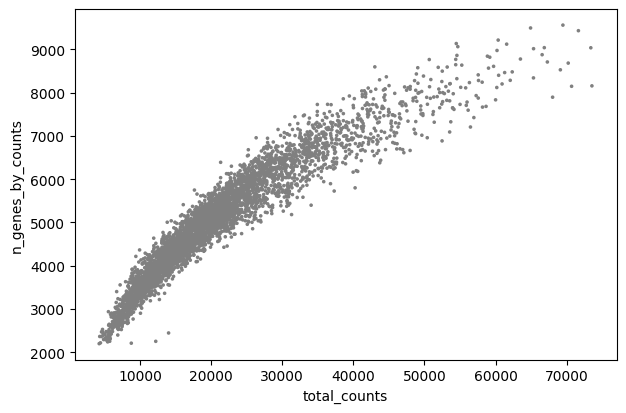

In [ ]:
# Visualise before QC
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4)
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

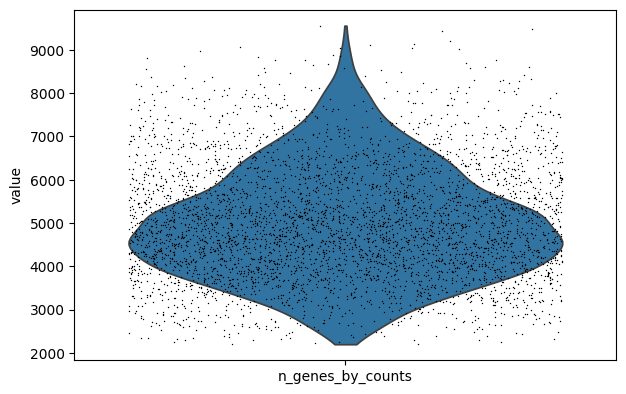

In [ ]:
sc.pl.violin(adata, ['n_genes_by_counts'], jitter=0.4)

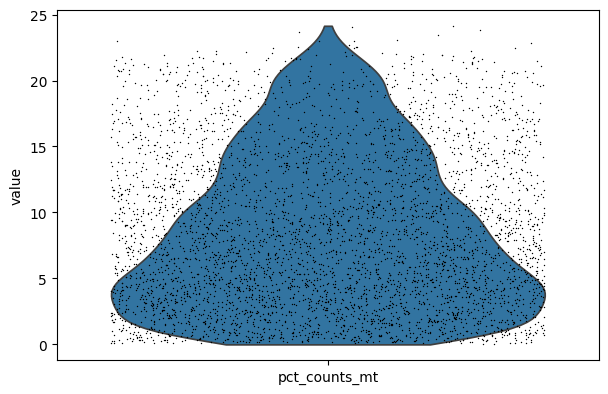

In [ ]:
sc.pl.violin(adata, ['pct_counts_mt'], jitter=0.4)

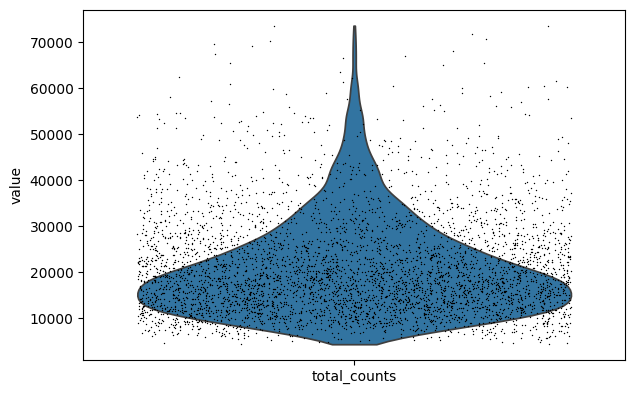

In [ ]:
sc.pl.violin(adata, ['total_counts'], jitter=0.4)

In [ ]:
sc.pp.filter_genes(adata, min_cells=3)

In [ ]:
# Normalise and log transform

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [ ]:
sc.pp.highly_variable_genes(adata, flavor='seurat', n_top_genes=2000)

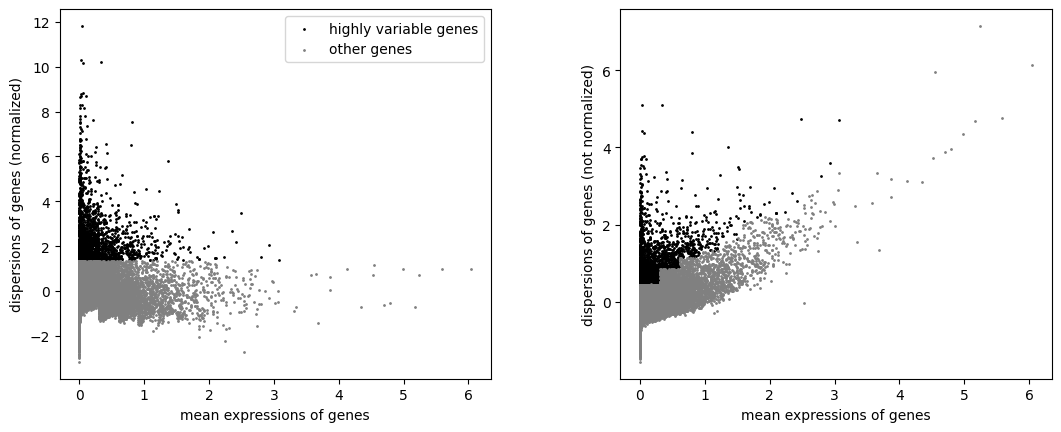

In [ ]:
sc.pl.highly_variable_genes(adata)

In [ ]:
# Scale data
sc.pp.scale(adata, max_value=10)
# Can regress out cell cycle stage etc if wanted:
# sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

/usr/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [ ]:
# Cluster using highly variable genes
sc.tl.pca(adata, use_highly_variable=True)
var_ratio = adata.uns['pca']['variance_ratio']

/usr/local/lib/python3.11/dist-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


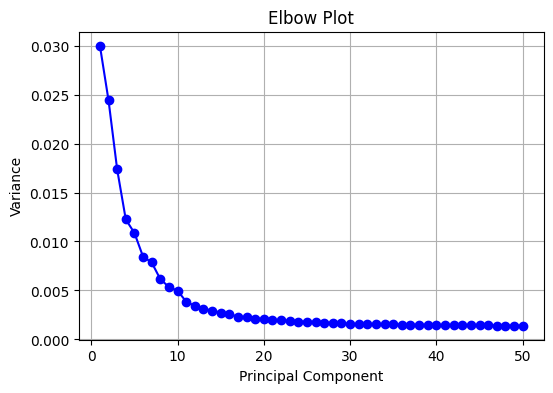

In [ ]:
# Elbow plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(var_ratio)+1), var_ratio, 'o-', color='blue')
plt.xlabel('Principal Component')
plt.ylabel('Variance')
plt.title('Elbow Plot')
plt.grid(True)
plt.show()

In [ ]:
# Neighbours after choosing the number of principal components
sc.pp.neighbors(adata, n_pcs=20)

In [ ]:
!pip install python-igraph
!pip install leidenalg

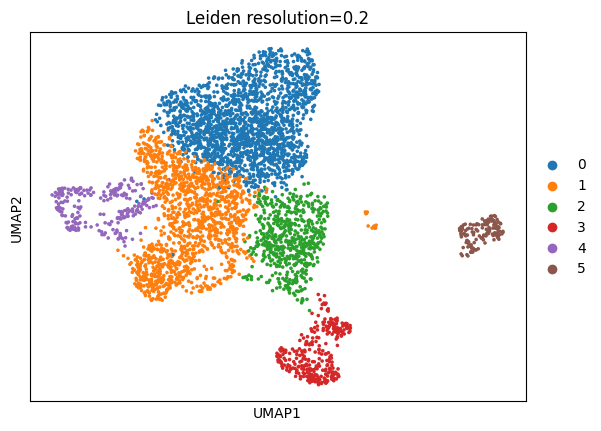

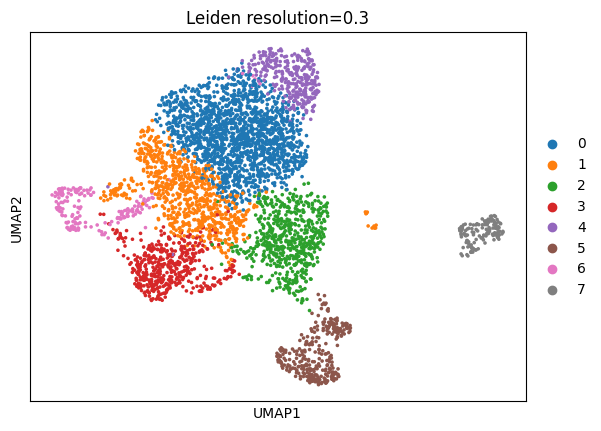

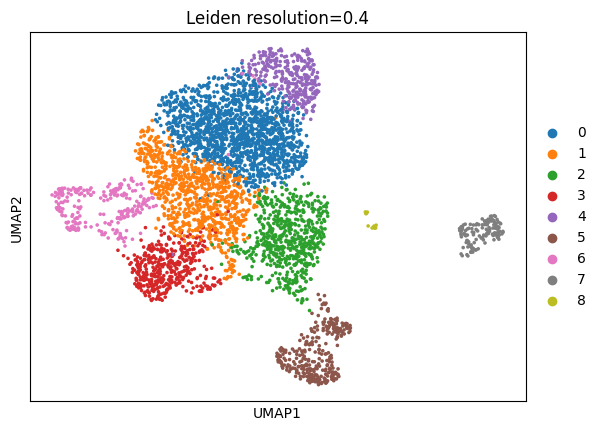

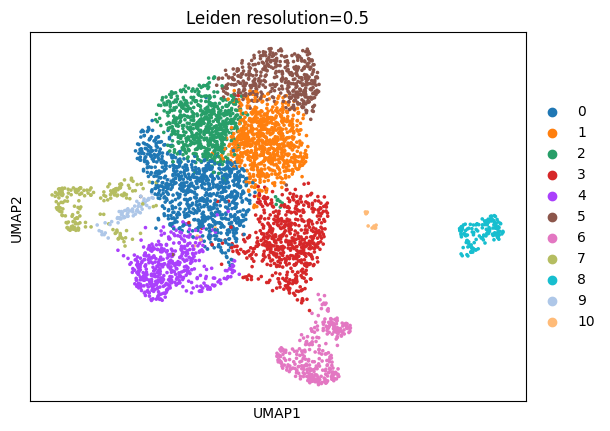

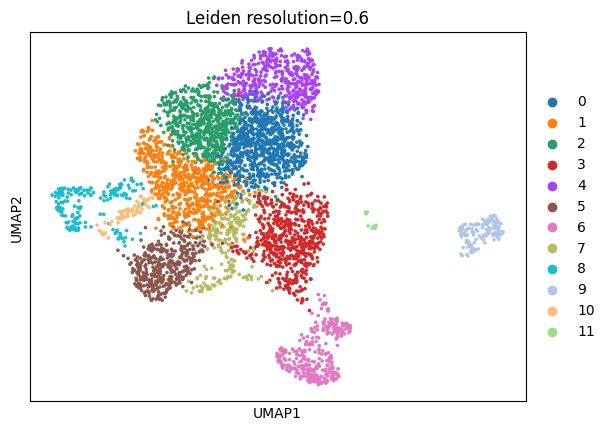

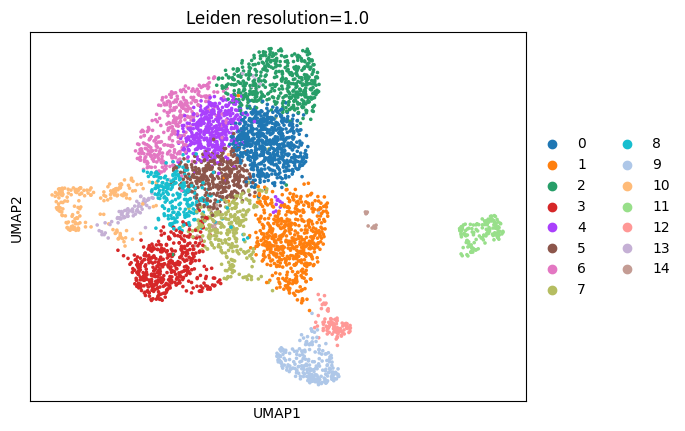

In [ ]:
# Test resolutions for clustering

sc.tl.umap(adata)

for res in [0.2,0.3,0.4,0.5,0.6, 1.0]:
    sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')
    sc.pl.umap(adata, color=f'leiden_{res}', title=f'Leiden resolution={res}')

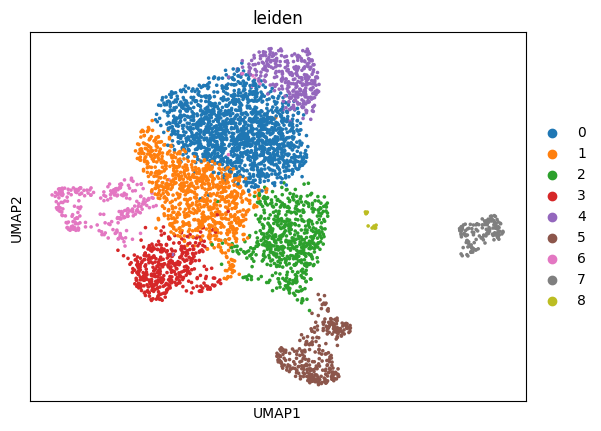

In [ ]:
sc.tl.leiden(adata, resolution= 0.4)
sc.pl.umap(adata, color= 'leiden')

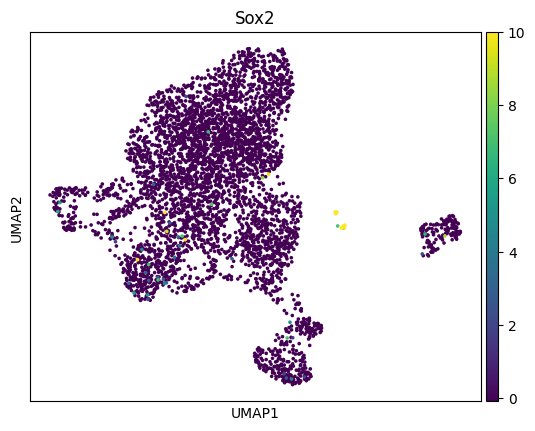

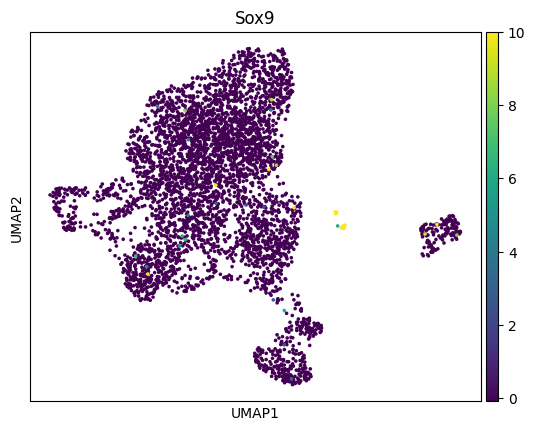

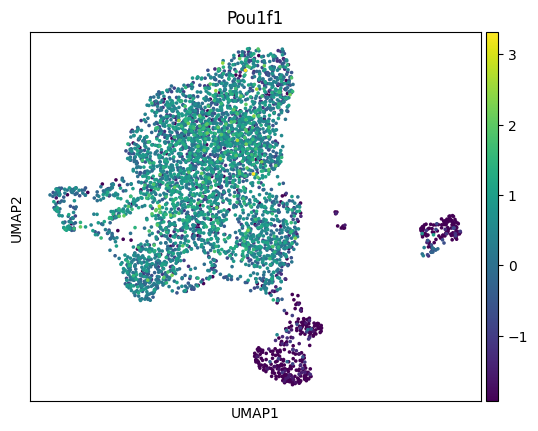

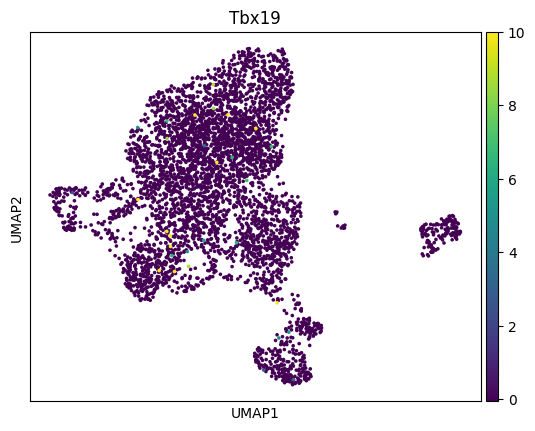

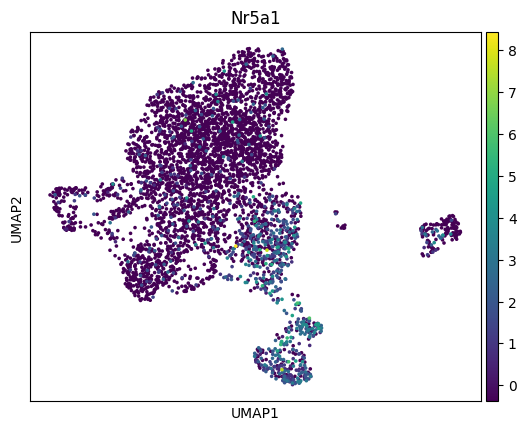

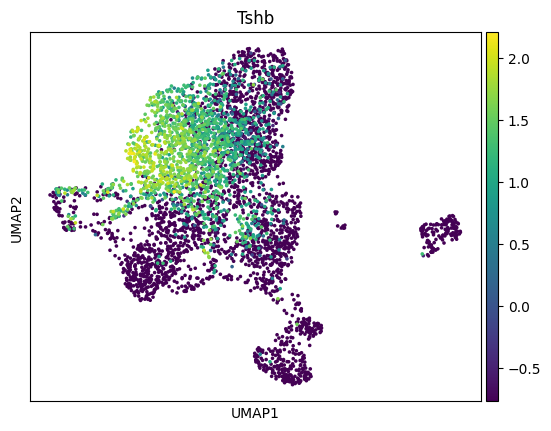

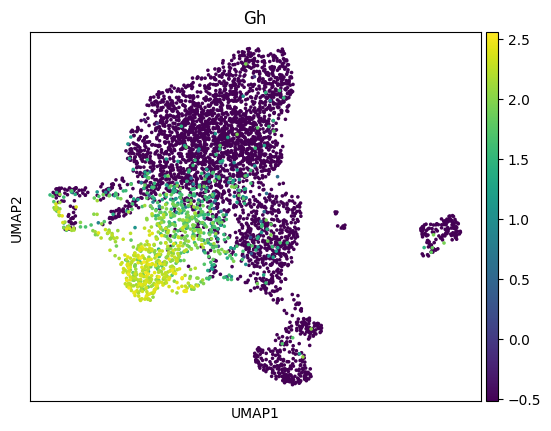

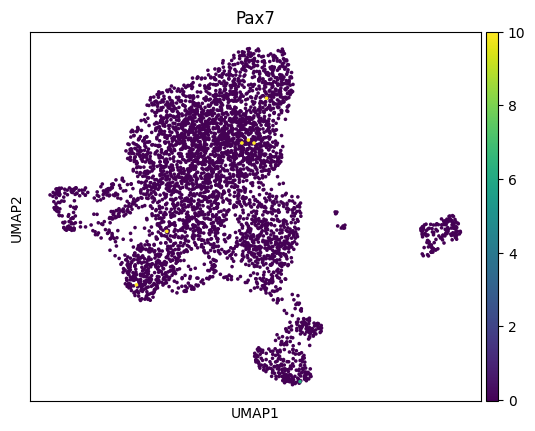

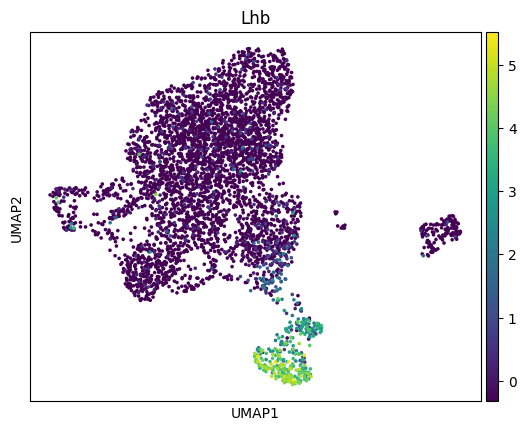

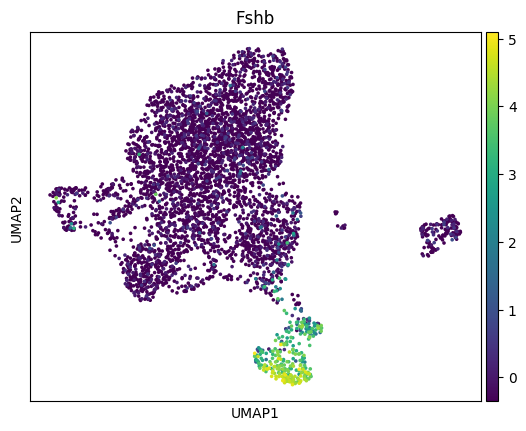

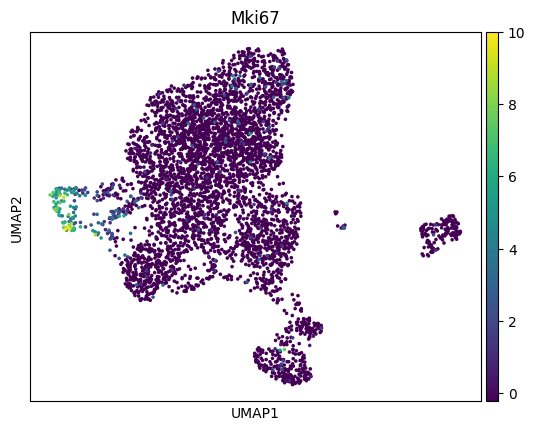

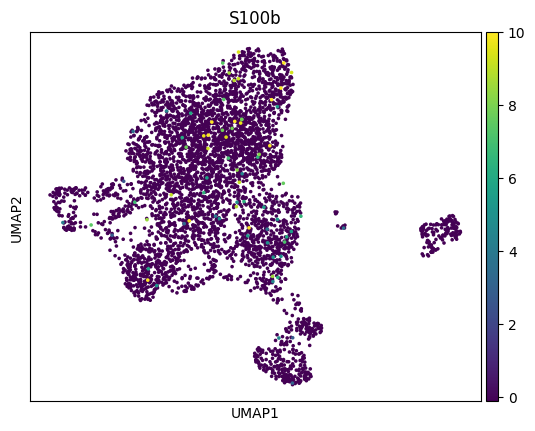

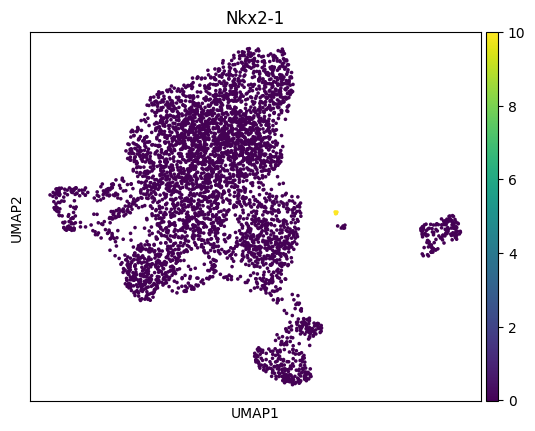

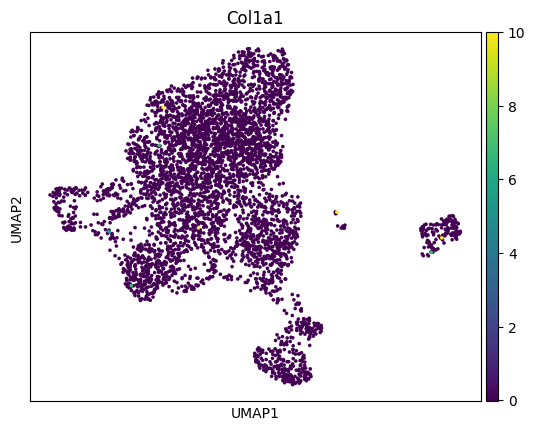

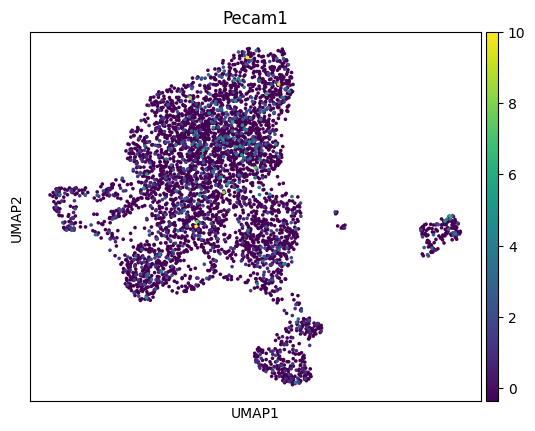

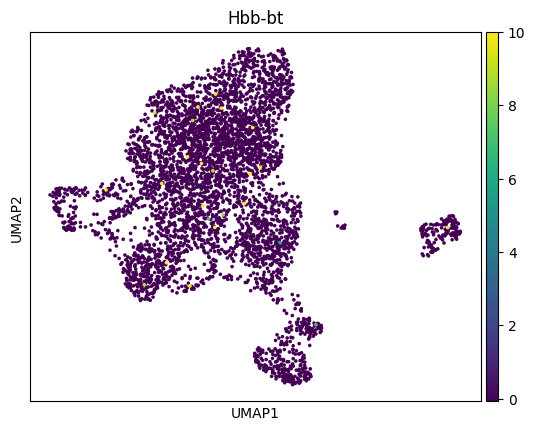

In [ ]:
# Plot UMAPS of key marker genes

genes = [
  'Sox2', 'Sox9', 'Pou1f1','Tbx19', 'Nr5a1', 'Tshb', 'Gh', 'Pax7', 'Lhb', 'Fshb','Mki67', 'S100b', 'Nkx2-1', 'Col1a1','Pecam1', 'Hbb-bt'
]
for gene in genes:
    sc.pl.umap(adata, color=gene, title=gene)

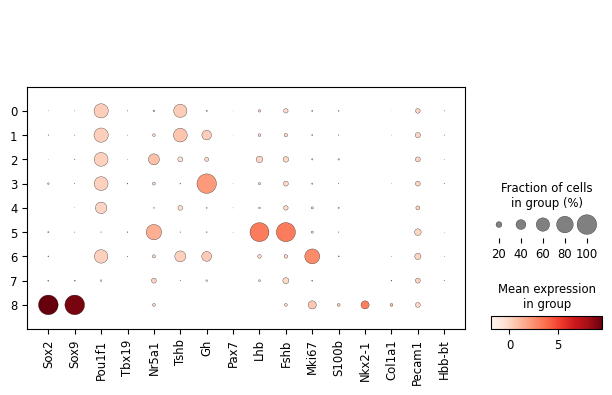

In [ ]:
# Dotplot of key cell-type markers
genes = [
    'Sox2', 'Sox9', 'Pou1f1','Tbx19', 'Nr5a1', 'Tshb', 'Gh',
     'Pax7', 'Lhb', 'Fshb','Mki67', 'S100b', 'Nkx2-1',  'Col1a1','Pecam1', 'Hbb-bt'
]

sc.pl.dotplot(adata, var_names=genes, groupby='leiden') #dendrogram=True

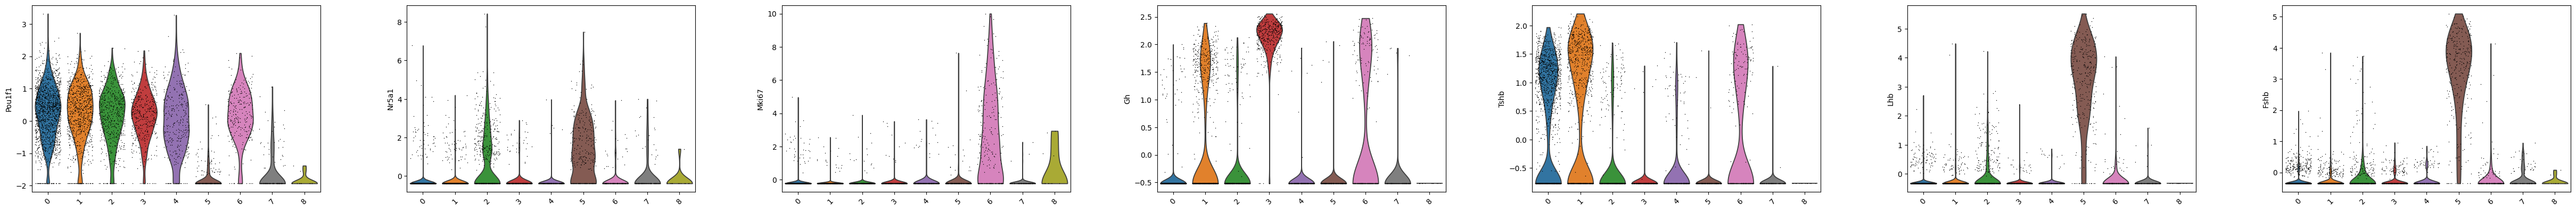

In [ ]:
sc.pl.violin(
    adata,
    keys=['Pou1f1', 'Nr5a1','Mki67', 'Gh', 'Tshb', 'Lhb', 'Fshb'],
    groupby='leiden',
    jitter=0.4,
    stripplot=True,
    rotation=45,
    multi_panel=True  # Plots each gene in a separate panel
)

In [ ]:
# Labelling cell types based on marker gene expression
0 - Pou1f1, Tshb - Thyrotrophs
1 - Pou1f1, Tshb, Gh - Thyrotrophs (mix with Somatos?)
2 - Pou1f1, Nr5a1, Tshb, Gh, Lhbm Fshb - ???????? (Thyrotrophs?)
3 - Pou1f1, Gh - Somatotrophs
4 - Pou1f1 - ???????????
5 - Nr5a1, Lhb, Fshb - Gonadotrophs
6 - Pou1f1, Tshb, Gh, Mki67 - ???????? Proliferating (Somatotrophs)
7 - Nr5a1, Fshb - Gonadotrophs
8 - Sox2, Sox9 - Stem Cells (Posterior?)

cell_type
Thyrotrophs     3307
Somatotrophs     664
Gonadotrophs     446
Stem Cells        13
Name: count, dtype: int64


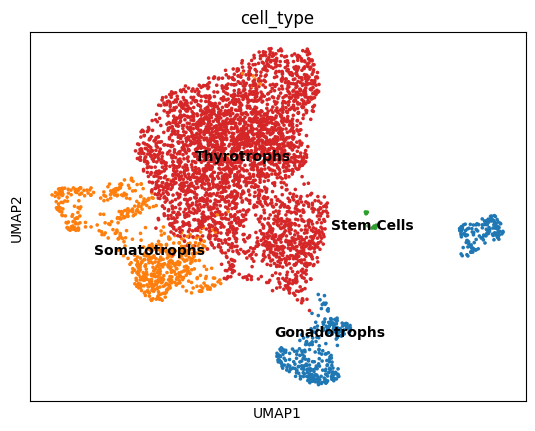

In [ ]:
# Assigning names to clusters
cluster_names = {
    '0': 'Thyrotrophs',
    '1': 'Thyrotrophs',
    '2': 'Thyrotrophs',
    '3': 'Somatotrophs',
    '4': 'Thyrotrophs',
    '5': 'Gonadotrophs',
    '6': 'Somatotrophs',
    '7': 'Gonadotrophs',
    '8': 'Stem Cells',

}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_names).astype('category')
# Check
print(adata.obs['cell_type'].value_counts())

sc.pl.umap(adata, color='cell_type', legend_loc='on data')


# NOTES on this dataset
## Tbx19 lineage missing, no Pomc exp
## Cluster 2 - mixture of Pou1f1, Nr5a1, Tshb, Gh, Lhb, Fshb exp (went with Thyro) - this cluster doesn't separate out even at higher res (up to 1)
## Cluster 4 - Pou1f1 progenitors? - No hormone exp apart from a bit of Tshb (went for Thyro)
## Cluster 6 - Proliferating cluster, mix of Gh and Tshb (went for Somato)
## Cluster 7 - really not obvious, out of the classical markers went for Gonados
## Cluster 8 - tiny cluster but v high in Sox2 and Sox9 (only one or two cells Nkx2-1 positive - these are likely posterior cells)

/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:482: 

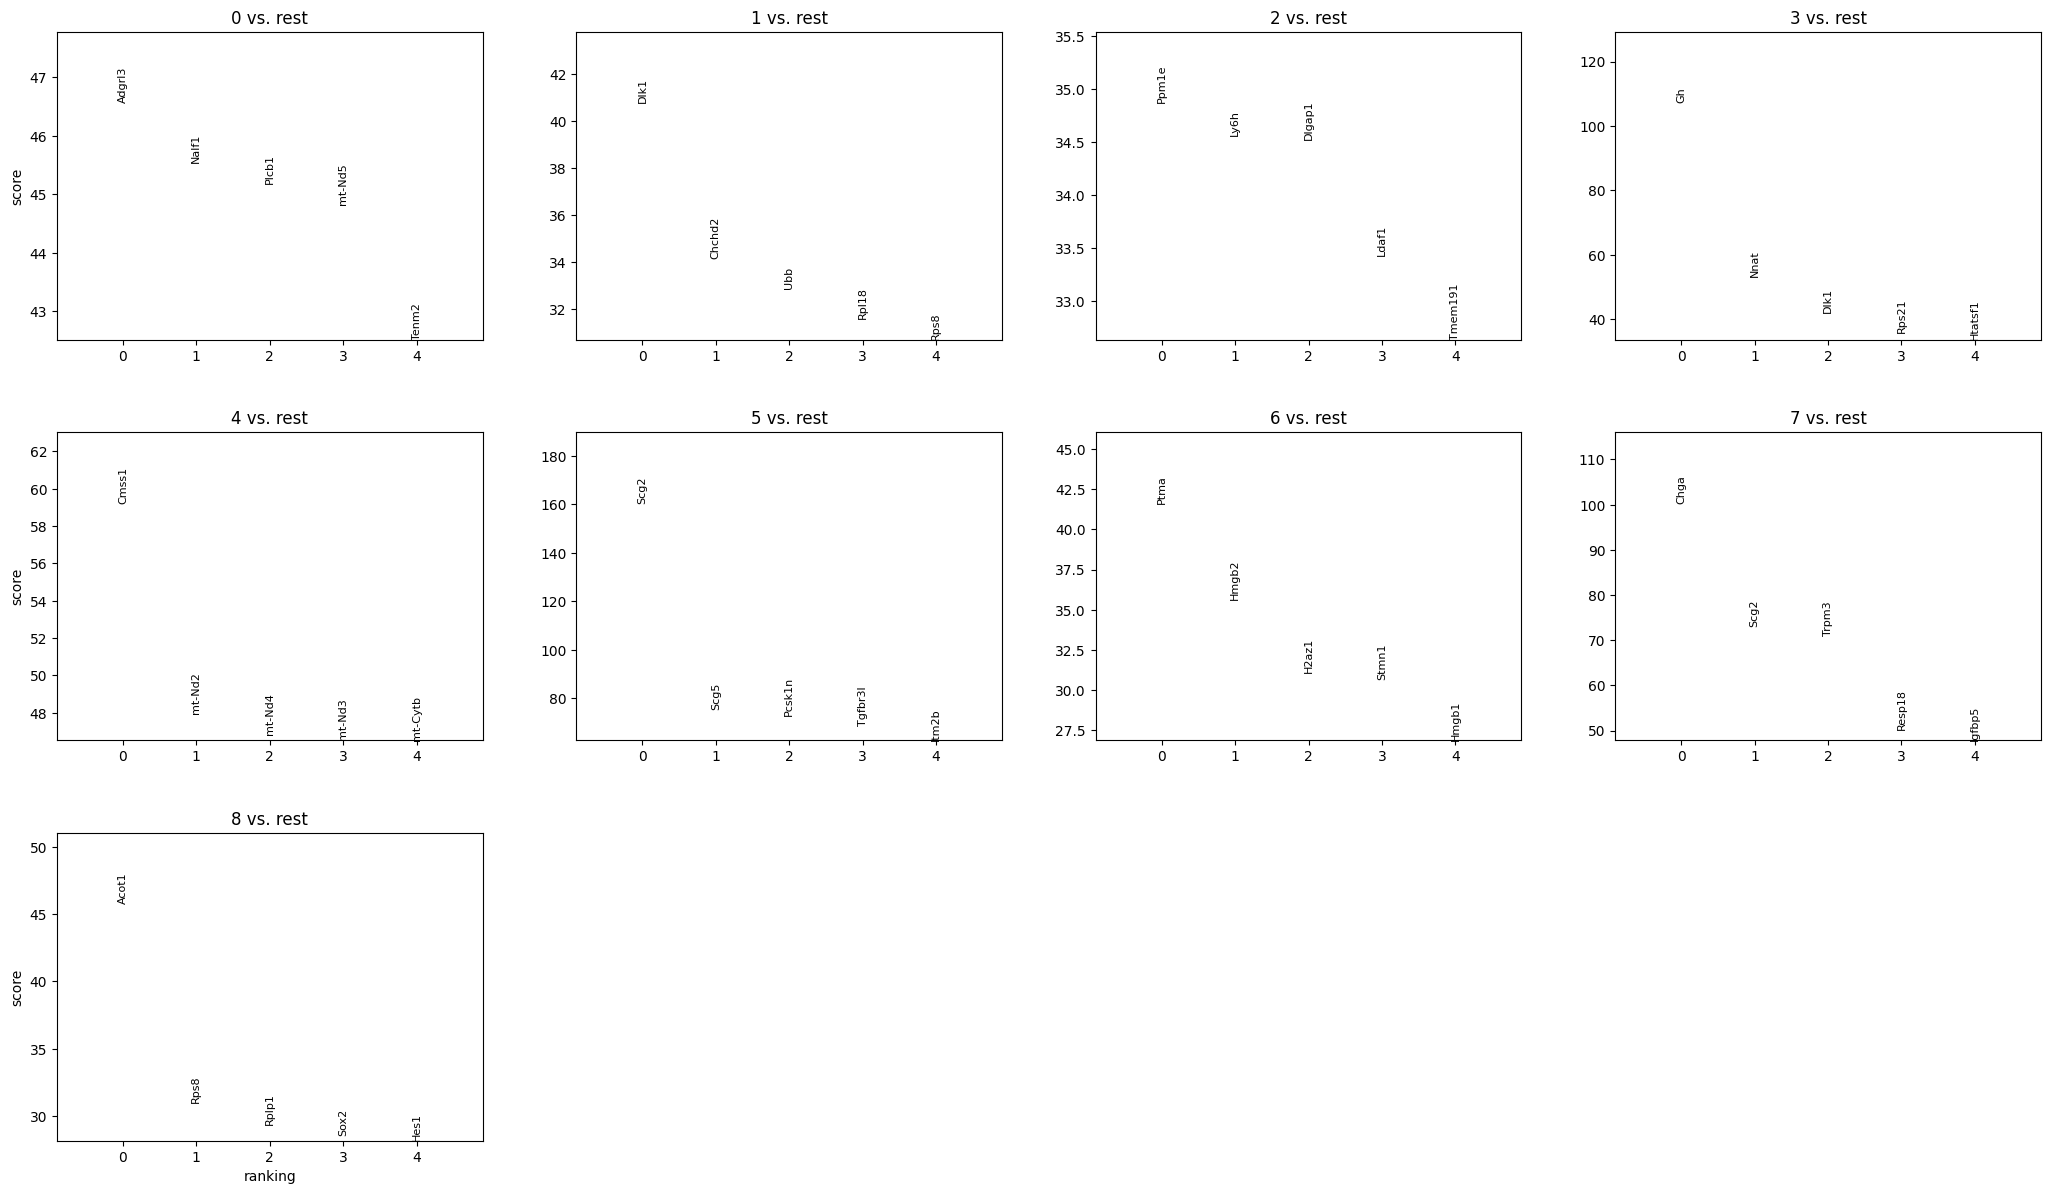

In [ ]:
# Check top 5 markers of each cluster
sc.tl.rank_genes_groups(adata, groupby='leiden', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False)

In [ ]:
adata.write('/content/drive/MyDrive/bence_project_july/SRX15581371_adata_annotated.h5ad')

In [ ]:
### EXPECTED CELL-TYPES AND ASSOCIATED MANUAL MARKERS

Corticotrophs - Tbx19, Pomc
Gonadotrophs - Nr5a1, Lhb, Fshb
Lactotrophs - Pou1f1, Prl
Melanotrophs - Tbx19, Pomc
Pituicytes - S100b, Sox2, Sox9
Somatotrophs - Pou1f1, Gh
Stem Cells - Sox2, Sox9
Thyrotrophs - Pou1f1, Tshb
Immune cells - C1qa
Mesenchymal cells - Col1a1
Endothelial cells - Pecam1
Erythrocytes - red blood cells - Hbb-bt